In [184]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [185]:
iris = load_iris()

In [186]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [187]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

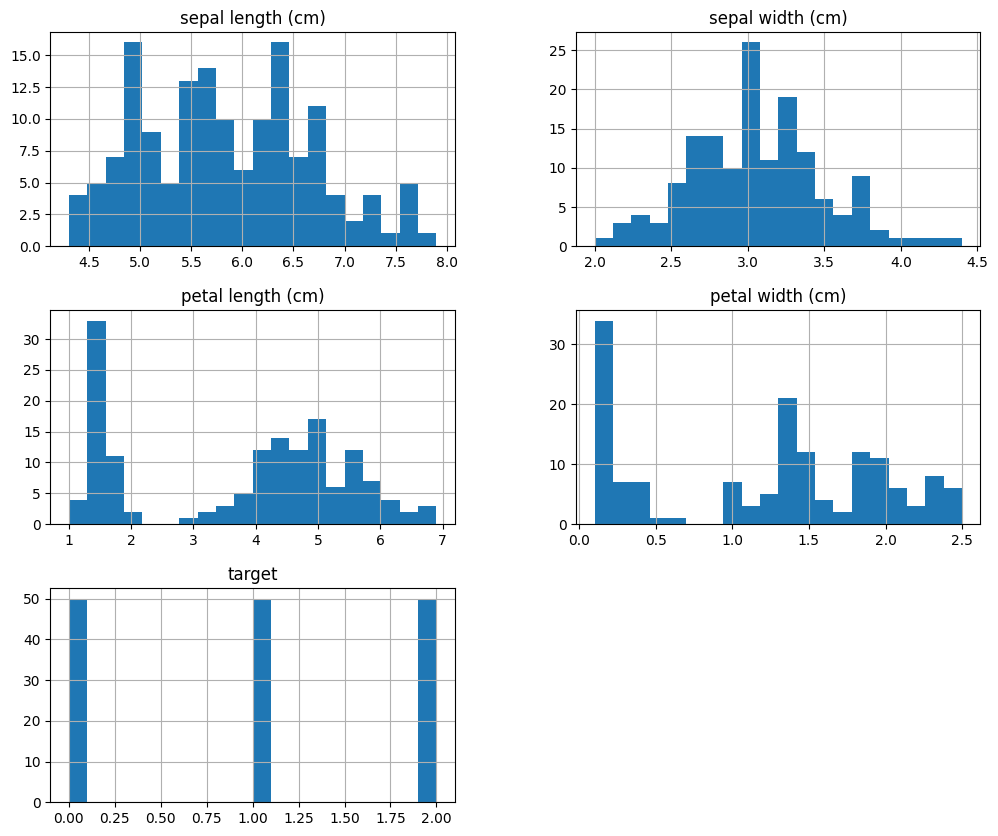

In [188]:
df.hist(bins=20, figsize=(12, 10))

<Axes: >

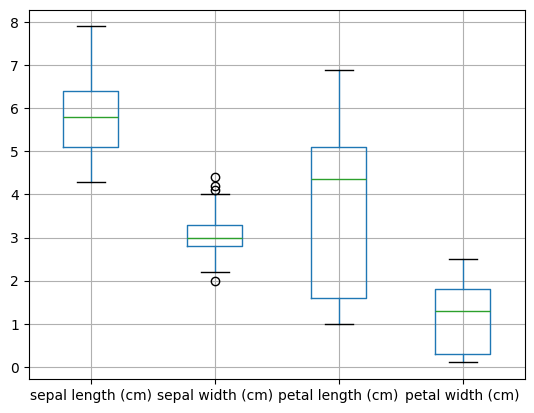

In [189]:
df.iloc[:, :-1].boxplot()

In [190]:
_X = df.iloc[:, :-1].values

In [191]:
df[["target"]]

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [192]:
_Y = pd.get_dummies(df["target"]).astype(float).values

In [193]:
_X_train, _X_test, _Y_train, _Y_test = train_test_split(
    _X, _Y, test_size=0.3, random_state=0
)

print(_X_train.shape)
print(_X_test.shape)
print(_Y_train.shape)
print(_Y_test.shape)

(105, 4)
(45, 4)
(105, 3)
(45, 3)


In [194]:
scX = StandardScaler()
X_train = scX.fit_transform(_X_train)
X_test = scX.transform(_X_test)

# Just to keep the flow consistent with last topic
Y_train = _Y_train
Y_test = _Y_test

<Axes: >

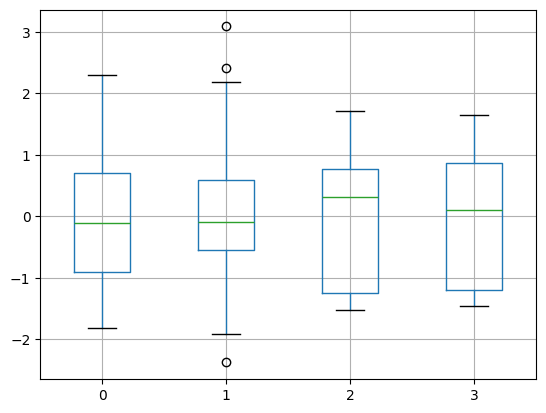

In [195]:
pd.DataFrame(data=X_train).boxplot()

In [196]:
X_train_pt = torch.from_numpy(X_train).float()
X_test_pt = torch.from_numpy(X_test).float()
Y_train_pt = torch.from_numpy(Y_train).float()
Y_test_pt = torch.from_numpy(Y_test).float()

In [197]:
num_features = _X.shape[1]
num_outputs = _Y.shape[1]
print(num_features, num_outputs)

4 3


In [198]:
class MyModel(nn.Module):
    def __init__(self, num_features, num_outputs):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(num_features, 24)
        self.fc2 = nn.Linear(24, 12)
        self.fc3 = nn.Linear(12, 6)
        self.fc4 = nn.Linear(6, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [199]:
model = MyModel(num_features=num_features, num_outputs=num_outputs)

In [200]:
from torchinfo import summary

summary(model, input=(40, 4))

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            120
├─Linear: 1-2                            300
├─Linear: 1-3                            78
├─Linear: 1-4                            21
├─ReLU: 1-5                              --
Total params: 519
Trainable params: 519
Non-trainable params: 0

In [201]:
n_epochs = 500

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

loss_arr = []
acc_arr = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    Y_pred = model(X_train_pt)
    loss = loss_fn(Y_pred, Y_train_pt)
    loss.backward()
    optimizer.step()

    epoch_train_loss = loss.item()
    loss_arr.append(epoch_train_loss)

    predicted_classes = torch.argmax(Y_pred, dim=1)
    true_classes = torch.argmax(Y_train_pt, dim=1)
    accuracy = (predicted_classes == true_classes).sum().item() / len(true_classes)
    acc_arr.append(accuracy)

<Axes: >

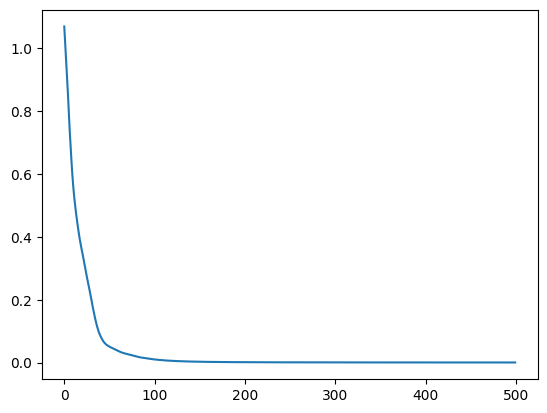

In [202]:
sns.lineplot(loss_arr)

<Axes: >

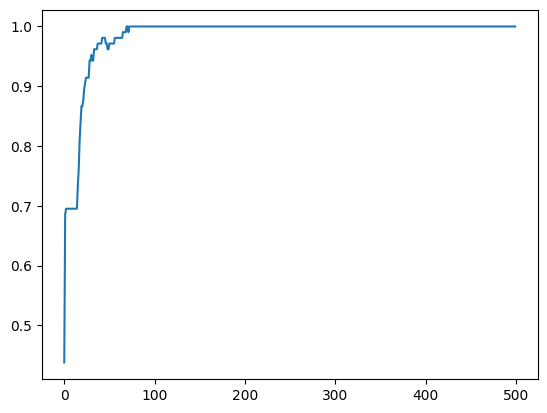

In [203]:
sns.lineplot(acc_arr)

In [204]:
with torch.no_grad():
    test_pred = model(X_test_pt)
    final_loss = loss_fn(test_pred, Y_test_pt)

    predicted_classes = torch.argmax(test_pred, dim=1)
    true_classes = torch.argmax(Y_test_pt, dim=1)
    final_accuracy = (predicted_classes == true_classes).sum().item() / len(true_classes)
    

In [205]:
print(final_loss, final_accuracy)

tensor(0.2779) 0.9777777777777777
